# Mini Vision Transformer (ViT) from Scratch

**Goal:** Implement every component of [An Image is Worth 16x16 Words (Dosovitskiy et al., 2020)](https://arxiv.org/abs/2010.11929) from scratch in PyTorch, sized for an M1 MacBook with 16 GB RAM.

**Dataset:** CIFAR-10 (32×32 RGB images, 10 classes).

**Architecture choices for "mini":**

| Hyperparameter | Value | Rationale |
|---|---|---|
| `image_size` | 32 | CIFAR-10 native resolution |
| `patch_size` | 4 | 32/4 = 8 patches per side → 64 total tokens |
| `embed_dim` | 128 | Small but enough for 4-head attention (128/4=32 per head) |
| `depth` | 4 | 4 transformer blocks |
| `num_heads` | 4 | Each head attends over d_k = 32 dimensions |
| `mlp_dim` | 256 | 2× expansion ratio (standard is 4× but we keep it small) |
| `num_classes` | 10 | CIFAR-10 |

**What we'll build (each component from scratch):**

```
Input Image (B, 3, 32, 32)
    │
    ▼
┌─────────────────────┐
│  1. Patch Embedding  │  Split into 4×4 patches, project to 128-dim
│     + CLS Token      │  Prepend a learnable [CLS] token
│     + Position Emb   │  Add learnable positional embeddings
└─────────────────────┘
    │  (B, 65, 128)
    ▼
┌─────────────────────┐
│  2. Transformer      │  × 4 blocks, each containing:
│     Encoder Blocks    │    - LayerNorm → Multi-Head Self-Attention → Residual
│                       │    - LayerNorm → MLP (FFN) → Residual
└─────────────────────┘
    │  (B, 65, 128)
    ▼
┌─────────────────────┐
│  3. Classification   │  Extract [CLS] token → LayerNorm → Linear → logits
│     Head             │
└─────────────────────┘
    │  (B, 10)
    ▼
  Logits
```

---
## 0. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional

# Device selection: MPS for Apple Silicon, CUDA for NVIDIA, else CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.9.1


---
## 1. Patch Embedding

The fundamental insight of ViT: treat an image as a sequence of patches, just like NLP treats a sentence as a sequence of tokens.

### The math

Given an image $\mathbf{x} \in \mathbb{R}^{H \times W \times C_{\text{in}}}$ (where $C_{\text{in}} = 3$ for RGB) and a patch size $P$:

1. **Divide** into a grid of $N = \frac{H}{P} \times \frac{W}{P}$ non-overlapping patches, each of shape $(P, P, C_{\text{in}})$.
   - For our setup: $N = \frac{32}{4} \times \frac{32}{4} = 8 \times 8 = 64$ patches.

2. **Flatten** each patch to a vector: $(P, P, C_{\text{in}}) \to (P^2 \cdot C_{\text{in}},) = (48,)$.

3. **Project** each flattened patch through a learnable linear layer: $\mathbf{E} \in \mathbb{R}^{(P^2 \cdot C_{\text{in}}) \times D}$, producing a $D$-dimensional embedding ($D = 128$).

$$\mathbf{z}_i = \mathbf{E} \cdot \text{flatten}(\text{patch}_i) + \mathbf{b} \quad \in \mathbb{R}^D$$

### The Conv2d trick

Instead of manually extracting patches and applying a linear layer, we can use a `Conv2d` with `kernel_size=P` and `stride=P`. This does exactly the same thing:
- The kernel covers one full patch (no overlap because stride = kernel size)
- Each of the $D$ output filters computes one dimension of the patch embedding
- The output shape is $(B, D, H/P, W/P)$, which we reshape to $(B, N, D)$

This is mathematically equivalent to flatten + linear but faster because it avoids explicit reshape operations and leverages optimised conv kernels.

In [2]:
class PatchEmbedding(nn.Module):
    """Convert a 2D image into a sequence of patch embeddings.

    Uses Conv2d with kernel_size=stride=patch_size as an efficient
    implementation of: extract patches → flatten → linear project.

    Args:
        image_size: Height/width of the input image (assumed square).
        patch_size: Height/width of each patch (must divide image_size).
        in_channels: Number of input channels (3 for RGB).
        embed_dim: Dimensionality of each patch embedding (D).
    """

    def __init__(
        self,
        image_size: int = 32,
        patch_size: int = 4,
        in_channels: int = 3,
        embed_dim: int = 128,
    ) -> None:
        super().__init__()
        assert image_size % patch_size == 0, (
            f"image_size ({image_size}) must be divisible by patch_size ({patch_size})"
        )
        self.num_patches = (image_size // patch_size) ** 2  # N = 64
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Conv2d(3, 128, kernel_size=4, stride=4)
        # - kernel covers exactly one patch (4×4 pixels)
        # - stride=4 means no overlap between patches
        # - 128 output channels = 128-dim embedding per patch
        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,  # output channels representing that many feature maps
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input images, shape (B, C_in, H, W).

        Returns:
            Patch embeddings, shape (B, N, D) where N = num_patches.
        """
        # x: (B, 3, 32, 32)
        x = self.projection(x)   # (B, 128, 8, 8) — one 128-dim vector per patch position
        x = x.flatten(2)          # (B, 128, 64) — merge spatial dims into sequence
        x = x.transpose(1, 2)     # (B, 64, 128) — (batch, num_patches, embed_dim)
        return x

### Visualise the patching process

Let's see what happens when we split an image into patches.

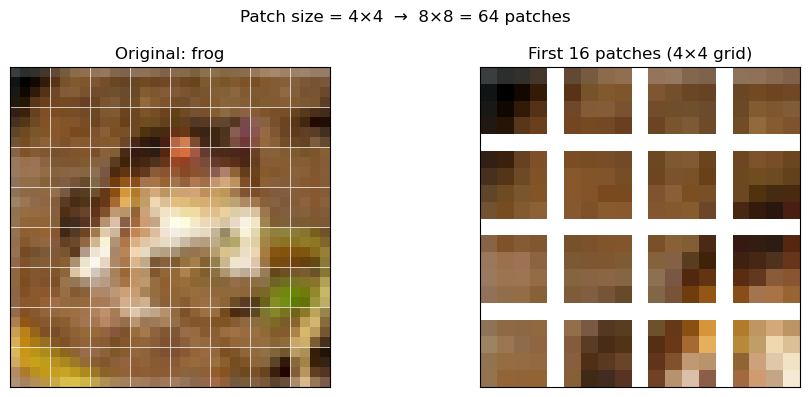

In [3]:
# Load a single CIFAR-10 image for visualisation
transform_vis = transforms.ToTensor()
cifar_vis = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_vis
)
sample_img, sample_label = cifar_vis[0]
class_names = cifar_vis.classes

PATCH_SIZE = 4
IMG_SIZE = 32
GRID = IMG_SIZE // PATCH_SIZE  # 8

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: original image with patch grid overlay
ax = axes[0]
ax.imshow(sample_img.permute(1, 2, 0))  # (C,H,W) → (H,W,C)
ax.set_title(f"Original: {class_names[sample_label]}")
for i in range(1, GRID):
    ax.axhline(y=i * PATCH_SIZE - 0.5, color="white", linewidth=0.5)
    ax.axvline(x=i * PATCH_SIZE - 0.5, color="white", linewidth=0.5)
ax.set_xticks([])
ax.set_yticks([])

# Right: first 16 patches as individual tiles
ax = axes[1]
patches = sample_img.unfold(1, PATCH_SIZE, PATCH_SIZE).unfold(2, PATCH_SIZE, PATCH_SIZE)
# patches shape: (3, 8, 8, 4, 4) → rearrange to grid of patches
patches = patches.permute(1, 2, 0, 3, 4)  # (8, 8, 3, 4, 4)

# Stitch first 4×4 patches into a mosaic with borders
mosaic = np.ones((4 * (PATCH_SIZE + 1) - 1, 4 * (PATCH_SIZE + 1) - 1, 3))
for row in range(4):
    for col in range(4):
        patch = patches[row, col].permute(1, 2, 0).numpy()  # (4, 4, 3)
        r0 = row * (PATCH_SIZE + 1)
        c0 = col * (PATCH_SIZE + 1)
        mosaic[r0:r0 + PATCH_SIZE, c0:c0 + PATCH_SIZE] = patch

ax.imshow(mosaic)
ax.set_title("First 16 patches (4×4 grid)")
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle(
    f"Patch size = {PATCH_SIZE}×{PATCH_SIZE}  →  {GRID}×{GRID} = {GRID**2} patches",
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [4]:
# Verify PatchEmbedding shapes
patch_embed = PatchEmbedding(image_size=32, patch_size=4, in_channels=3, embed_dim=128)
dummy = torch.randn(2, 3, 32, 32)  # batch of 2 images
tokens = patch_embed(dummy)
print(f"Input shape:  {dummy.shape}    →  (B, C_in, H, W)")
print(f"Output shape: {tokens.shape}  →  (B, N_patches, D)")
print(f"Each image is now a sequence of {tokens.shape[1]} tokens, each {tokens.shape[2]}-dim")

Input shape:  torch.Size([2, 3, 32, 32])    →  (B, C_in, H, W)
Output shape: torch.Size([2, 64, 128])  →  (B, N_patches, D)
Each image is now a sequence of 64 tokens, each 128-dim


---
## 2. CLS Token and Positional Embedding

Two critical additions before the patch tokens enter the transformer:

### CLS Token

A **learnable** vector $\mathbf{z}_{\text{cls}} \in \mathbb{R}^{D}$ that is prepended to the patch sequence. After passing through all transformer layers, this token's output is used for classification. It acts as a "summary" of the entire image.

Why not just average-pool all patch tokens? You could (and some ViT variants do), but the CLS token approach is inherited from BERT and has the advantage that the transformer can learn to route information from all patches into this one dedicated token.

After prepending:
$$\mathbf{z}_0 = [\mathbf{z}_{\text{cls}} \;|\; \mathbf{z}_1,\, \mathbf{z}_2,\, \dots,\, \mathbf{z}_N] \quad \in \mathbb{R}^{(N+1) \times D}$$

### Positional Embedding

Self-attention is **permutation-equivariant** — it treats the input as a set, not a sequence. Without positional information, the model cannot distinguish patch (0,0) from patch (7,7). We add learnable positional embeddings:

$$\mathbf{z}_0' = \mathbf{z}_0 + \mathbf{E}_{\text{pos}}, \qquad \mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$$

Each of the $N + 1$ positions (CLS + 64 patches) gets its own learnable $D$-dimensional vector added to its embedding. The model learns spatial relationships through these embeddings.

> **Note:** The original ViT paper found that learnable 1D positional embeddings work just as well as 2D-aware variants. The model discovers the 2D grid structure from data.

---
## 3. Multi-Head Self-Attention (MHSA)

This is the core mechanism that allows each patch to attend to every other patch.

### Single-head attention

Given an input sequence $\mathbf{Z} \in \mathbb{R}^{N' \times D}$ (where $N' = N + 1$ including CLS):

1. **Project** to queries, keys, values with learned weight matrices:
$$Q = \mathbf{Z} W_Q, \quad K = \mathbf{Z} W_K, \quad V = \mathbf{Z} W_V$$
where $W_Q, W_K, W_V \in \mathbb{R}^{D \times d_k}$ and $d_k$ is the per-head dimension.

2. **Compute attention scores** — how much each token should attend to each other token:
$$A = \operatorname{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) \quad \in \mathbb{R}^{N' \times N'}$$
The $\sqrt{d_k}$ scaling prevents dot products from growing large and pushing softmax into saturation.

3. **Aggregate values** weighted by attention:
$$\text{head} = A \cdot V \quad \in \mathbb{R}^{N' \times d_k}$$

### Multi-head: why and how

A single attention head can only express one "type" of relationship. Multi-head attention runs $h$ independent heads in parallel, each with its own Q/K/V projections, then concatenates:

$$\operatorname{MHSA}(\mathbf{Z}) = \operatorname{Concat}(\text{head}_1, \dots, \text{head}_h) \cdot W_O$$

where $W_O \in \mathbb{R}^{(h \cdot d_k) \times D}$ projects the concatenated heads back to $D$ dimensions.

With $D = 128$ and $h = 4$: each head operates on $d_k = D / h = 32$ dimensions.

### The reshape trick for efficient multi-head

Rather than using $h$ separate linear layers, we use a single `Linear(D, D)` for each of Q, K, V and **reshape** the output to split heads:

```
(B, N', D)  →  Linear  →  (B, N', D)  →  reshape  →  (B, h, N', d_k)
```

This is equivalent to $h$ separate `Linear(D, d_k)` layers but uses a single, larger matrix multiply — more GPU-friendly.

In [5]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention (MHSA) for ViT.

    Implements scaled dot-product attention with multiple heads.
    Optionally returns attention weights for visualisation.

    Args:
        embed_dim: Total embedding dimension D.
        num_heads: Number of attention heads h. Must divide embed_dim.
        attn_dropout: Dropout rate on attention weights.
        proj_dropout: Dropout rate on the output projection.
    """

    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 4,
        attn_dropout: float = 0.0,
        proj_dropout: float = 0.0,
    ) -> None:
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
        )
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads  # d_k = 32
        self.scale = self.head_dim ** -0.5       # 1/sqrt(d_k) for scaling

        # Single linear layer for Q, K, V combined (efficient)
        # Output has 3 * embed_dim = 3 * 128 = 384 dimensions:
        #   first 128 = Q, next 128 = K, last 128 = V
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)

        # Output projection: W_O that maps concatenated heads back to D
        self.proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(attn_dropout)
        self.proj_dropout = nn.Dropout(proj_dropout)

    def forward(
        self,
        x: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Forward pass.

        Args:
            x: Input sequence, shape (B, N', D).
            return_attention: If True, also return attention weight matrix.

        Returns:
            out: Output sequence, shape (B, N', D).
            attn_weights: Attention matrix (B, h, N', N') if requested, else None.
        """
        B, N, D = x.shape

        # --- Step 1: Compute Q, K, V in one shot ---
        # (B, N', D) → Linear → (B, N', 3*D)
        qkv = self.qkv(x)

        # Reshape to separate Q, K, V and split heads:
        # (B, N', 3*D) → (B, N', 3, h, d_k) → (3, B, h, N', d_k)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)  # self.head_dim = embed_dim // num_heads
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, h, N', d_k)
        q, k, v = qkv.unbind(0)             # each: (B, h, N', d_k)

        # --- Step 2: Scaled dot-product attention ---
        # (B, h, N', d_k) @ (B, h, d_k, N') → (B, h, N', N')
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale
        attn_weights = attn_scores.softmax(dim=-1)  # normalise over keys
        attn_weights = self.attn_dropout(attn_weights)

        # --- Step 3: Aggregate values ---
        # (B, h, N', N') @ (B, h, N', d_k) → (B, h, N', d_k)
        out = attn_weights @ v

        # --- Step 4: Concatenate heads and project ---
        # (B, h, N', d_k) → (B, N', h, d_k) → (B, N', D)
        out = out.transpose(1, 2).reshape(B, N, D)

        # Output projection: W_O
        out = self.proj(out)       # (B, N', D)
        out = self.proj_dropout(out)

        return out, (attn_weights if return_attention else None)

In [6]:
# Verify MHSA shapes
mhsa = MultiHeadSelfAttention(embed_dim=128, num_heads=4)
dummy_seq = torch.randn(2, 65, 128)  # B=2, N'=65 (64 patches + CLS), D=128
out, attn = mhsa(dummy_seq, return_attention=True)

print(f"Input shape:            {dummy_seq.shape}  →  (B, N', D)")
print(f"Output shape:           {out.shape}  →  (B, N', D)  [same as input]")
print(f"Attention weight shape: {attn.shape}  →  (B, heads, N', N')")
print(f"\nAttention row sums (should be 1.0): {attn[0, 0, 0].sum().item():.4f}")

Input shape:            torch.Size([2, 65, 128])  →  (B, N', D)
Output shape:           torch.Size([2, 65, 128])  →  (B, N', D)  [same as input]
Attention weight shape: torch.Size([2, 4, 65, 65])  →  (B, heads, N', N')

Attention row sums (should be 1.0): 1.0000


---
## 4. MLP (Feed-Forward Network)

Each transformer block contains an MLP applied independently to each token:

$$\operatorname{MLP}(\mathbf{z}) = W_2 \cdot \operatorname{GELU}(W_1 \cdot \mathbf{z} + \mathbf{b}_1) + \mathbf{b}_2$$

where:
- $W_1 \in \mathbb{R}^{D \times D_{\text{mlp}}}$ expands the representation (128 → 256)
- $W_2 \in \mathbb{R}^{D_{\text{mlp}} \times D}$ projects it back (256 → 128)

The expansion creates a wider "bottleneck" where the model can compute non-linear features before compressing back. GELU (Gaussian Error Linear Unit) is the standard non-linearity in transformers — smoother than ReLU.

In [7]:
class MLP(nn.Module):
    """Feed-forward network for each transformer block.

    Two-layer MLP with GELU activation and dropout.
    Applied independently (and identically) to every token.

    Args:
        embed_dim: Input/output dimension D.
        mlp_dim: Hidden layer dimension (expansion).
        dropout: Dropout probability.
    """

    def __init__(
        self,
        embed_dim: int = 128,
        mlp_dim: int = 256,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)   # expand: D → D_mlp
        self.act = nn.GELU()                         # smoother than ReLU
        self.fc2 = nn.Linear(mlp_dim, embed_dim)    # compress: D_mlp → D
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, N', D) → (B, N', D)"""
        x = self.fc1(x)       # (B, N', D) → (B, N', D_mlp)
        x = self.act(x)       # non-linearity
        x = self.dropout(x)
        x = self.fc2(x)       # (B, N', D_mlp) → (B, N', D)
        x = self.dropout(x)
        return x

---
## 5. Transformer Encoder Block

Each block applies two sub-layers with **pre-norm residual connections** (ViT uses pre-norm, unlike the original Transformer which uses post-norm):

$$\mathbf{z}' = \operatorname{MHSA}\bigl(\operatorname{LN}(\mathbf{z})\bigr) + \mathbf{z} \qquad \text{(attention + residual)}$$
$$\mathbf{z}'' = \operatorname{MLP}\bigl(\operatorname{LN}(\mathbf{z}')\bigr) + \mathbf{z}' \qquad \text{(MLP + residual)}$$

**Pre-norm vs post-norm:** LayerNorm is applied *before* each sub-layer (pre-norm), not after. Pre-norm has been shown to stabilise training, especially for deeper models, because the residual path carries unnormalised gradients directly.

**Residual connections** ($+ \mathbf{z}$): these allow gradients to flow directly through the network without passing through non-linearities, preventing vanishing gradients in deep stacks.

In [8]:
class TransformerBlock(nn.Module):
    """Single transformer encoder block with pre-norm residual connections.

    Architecture:
        x → LN → MHSA → + (residual) → LN → MLP → + (residual) → out

    Args:
        embed_dim: Token embedding dimension D.
        num_heads: Number of attention heads.
        mlp_dim: Hidden dimension of the MLP.
        dropout: Dropout rate for attention and MLP.
    """

    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 4,
        mlp_dim: int = 256,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()

        # Pre-norm: LayerNorm before each sub-layer
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Sub-layer 1: Multi-head self-attention
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            attn_dropout=dropout,
            proj_dropout=dropout,
        )

        # Sub-layer 2: Feed-forward MLP
        self.mlp = MLP(
            embed_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )

    def forward(
        self,
        x: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Forward pass.

        Args:
            x: Input sequence, shape (B, N', D).
            return_attention: If True, return attention weights from this block.

        Returns:
            out: Output sequence, shape (B, N', D).
            attn_weights: Attention matrix or None.
        """
        # Sub-layer 1: LN → MHSA → residual
        attn_out, attn_weights = self.attn(
            self.norm1(x), return_attention=return_attention
        )
        x = x + attn_out  # residual connection

        # Sub-layer 2: LN → MLP → residual
        x = x + self.mlp(self.norm2(x))  # residual connection

        return x, attn_weights

In [9]:
# Verify TransformerBlock shapes
block = TransformerBlock(embed_dim=128, num_heads=4, mlp_dim=256)
dummy_seq = torch.randn(2, 65, 128)
out, attn = block(dummy_seq, return_attention=True)

print(f"Input shape:  {dummy_seq.shape}")
print(f"Output shape: {out.shape}  [same — transformer preserves sequence shape]")
print(f"Attention:    {attn.shape}")

Input shape:  torch.Size([2, 65, 128])
Output shape: torch.Size([2, 65, 128])  [same — transformer preserves sequence shape]
Attention:    torch.Size([2, 4, 65, 65])


---
## 6. Full Vision Transformer

Now we assemble everything into the complete ViT model:

1. `PatchEmbedding` — image → patch tokens
2. Prepend `[CLS]` token
3. Add positional embeddings
4. Pass through `depth` transformer blocks
5. Extract `[CLS]` output → LayerNorm → Linear → class logits

In [10]:
class MiniViT(nn.Module):
    """Mini Vision Transformer for image classification.

    Implements the full ViT architecture from scratch:
    patch embedding → [CLS] + positional encoding → transformer encoder → classifier.

    Args:
        image_size: Input image size (assumed square).
        patch_size: Size of each patch.
        in_channels: Number of image channels.
        num_classes: Number of output classes.
        embed_dim: Transformer embedding dimension D.
        depth: Number of transformer blocks.
        num_heads: Number of attention heads per block.
        mlp_dim: Hidden dimension of the MLP in each block.
        dropout: Dropout rate.
        emb_dropout: Dropout rate after positional embedding.
    """

    def __init__(
        self,
        image_size: int = 32,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = 10,
        embed_dim: int = 128,
        depth: int = 4,
        num_heads: int = 4,
        mlp_dim: int = 256,
        dropout: float = 0.1,
        emb_dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        num_patches = (image_size // patch_size) ** 2  # N = 64

        # --- Component 1: Patch embedding ---
        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )

        # --- Component 2: CLS token ---
        # Learnable parameter, shape (1, 1, D) — will be expanded to batch size
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # --- Component 3: Positional embedding ---
        # One embedding per position: N patches + 1 CLS = N+1 total
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.emb_dropout = nn.Dropout(emb_dropout)

        # --- Component 4: Transformer encoder ---
        # Stack of `depth` identical blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        # --- Component 5: Classification head ---
        self.norm = nn.LayerNorm(embed_dim)  # final norm on CLS token
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialise CLS and positional embeddings from a normal distribution
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(
        self,
        x: torch.Tensor,
        return_attention: bool = False,
    ) -> tuple[torch.Tensor, Optional[list[torch.Tensor]]]:
        """Forward pass.

        Args:
            x: Input images, shape (B, C_in, H, W).
            return_attention: If True, collect attention weights from all blocks.

        Returns:
            logits: Class logits, shape (B, num_classes).
            all_attn: List of attention weight tensors (one per block) or None.
        """
        B = x.shape[0]

        # Step 1: Patch embedding
        # (B, 3, 32, 32) → (B, 64, 128)
        tokens = self.patch_embed(x)

        # Step 2: Prepend CLS token
        # cls_token is (1, 1, 128) → expand to (B, 1, 128)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # broadcast over batch
        # Concatenate: (B, 1, 128) + (B, 64, 128) → (B, 65, 128)
        tokens = torch.cat([cls_tokens, tokens], dim=1)

        # Step 3: Add positional embeddings
        # pos_embed is (1, 65, 128) — broadcasts over batch via +
        tokens = tokens + self.pos_embed
        tokens = self.emb_dropout(tokens)

        # Step 4: Pass through transformer blocks
        all_attn = []
        for block in self.blocks:
            tokens, attn_weights = block(tokens, return_attention=return_attention)
            if return_attention:
                all_attn.append(attn_weights)

        # Step 5: Classification head
        # Extract CLS token (position 0) from the final layer output
        cls_output = tokens[:, 0]           # (B, 128)
        cls_output = self.norm(cls_output)   # final LayerNorm
        logits = self.head(cls_output)       # (B, 10)

        return logits, (all_attn if return_attention else None)

In [11]:
# Instantiate and inspect the model
model = MiniViT(
    image_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=128,
    depth=4,
    num_heads=4,
    mlp_dim=256,
    dropout=0.1,
    emb_dropout=0.1,
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (FP32):    ~{total_params * 4 / 1024**2:.1f} MB")

# Test forward pass
dummy_images = torch.randn(4, 3, 32, 32)
logits, attn_list = model(dummy_images, return_attention=True)
print(f"\nInput shape:  {dummy_images.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Attention maps: {len(attn_list)} blocks × {attn_list[0].shape}")

Total parameters:     546,186
Trainable parameters: 546,186
Model size (FP32):    ~2.1 MB

Input shape:  torch.Size([4, 3, 32, 32])
Logits shape: torch.Size([4, 10])
Attention maps: 4 blocks × torch.Size([4, 4, 65, 65])


In [12]:
# Parameter breakdown by component
print("Parameter breakdown:")
print(f"{'Component':<30} {'Parameters':>12}")
print("-" * 44)

components = {
    "Patch embedding (Conv2d)": model.patch_embed,
    "CLS token": [model.cls_token],
    "Positional embedding": [model.pos_embed],
    "Transformer blocks": model.blocks,
    "Final LayerNorm": model.norm,
    "Classification head": model.head,
}

for name, module in components.items():
    if isinstance(module, list):
        count = sum(p.numel() for p in module)
    else:
        count = sum(p.numel() for p in module.parameters())
    print(f"{name:<30} {count:>12,}")

Parameter breakdown:
Component                        Parameters
--------------------------------------------
Patch embedding (Conv2d)              6,272
CLS token                               128
Positional embedding                  8,320
Transformer blocks                  529,920
Final LayerNorm                         256
Classification head                   1,290


---
## 7. Data Loading and Augmentation

CIFAR-10: 60,000 32×32 RGB images across 10 classes (50k train, 10k test).

We apply light data augmentation during training to help the model generalise — ViTs are known to be data-hungry, so augmentation matters more here than for CNNs.

In [13]:
# Data augmentation and normalisation
# CIFAR-10 per-channel mean and std (precomputed)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),    # random crop with padding
    transforms.RandomHorizontalFlip(),         # 50% horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Load datasets
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

# DataLoaders — batch_size=128 fits comfortably in 16 GB
# pin_memory is a CUDA-only optimisation (pinned host memory for faster H→D transfers).
# On MPS (Apple Silicon) it has no benefit and can cause warnings; disable it there.
_pin = device.type == "cuda"

# num_workers: number of CPU processes used to prefetch batches in parallel.
#   - Linux   : fork() is the default start method → safe to use multiple workers.
#   - macOS   : spawn() is the default (since Python 3.8). Using workers > 0
#               causes macOS to emit harmless "MallocStackLogging" noise to stderr
#               for every spawned worker process. Since MPS is the GPU bottleneck
#               anyway (not data loading), num_workers=0 is cleaner here.
#   - Windows : spawn() + Jupyter interaction can be fragile; 0 is the safe default.
# os.cpu_count() returns logical cores; cap at 4 to stay laptop-friendly.
import os, platform
_sys = platform.system()
if _sys == "Linux":
    _num_workers = min(4, os.cpu_count() or 1)
else:                           # macOS or Windows: avoid spawn noise / issues
    _num_workers = 0

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=_num_workers, pin_memory=_pin,
)
test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False,
    num_workers=_num_workers, pin_memory=_pin,
)
print(f"num_workers={_num_workers}  (platform: {_sys})")

print(f"Training samples:   {len(train_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Training batches:   {len(train_loader)}")
print(f"Classes: {train_dataset.classes}")

Training samples:   50,000
Test samples:       10,000
Training batches:   391
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 8. Training Loop

We use:
- **AdamW** optimiser (Adam with decoupled weight decay — standard for transformers)
- **Cosine annealing** learning rate schedule with linear warmup
- **Cross-entropy** loss

Training for 20 epochs should take ~5-10 minutes on MPS. Don't expect ResNet-level accuracy — ViTs typically need more data or pretraining to match CNNs on small datasets. The goal here is to learn the architecture, not to achieve SOTA.

In [14]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epoch: int,
) -> tuple[float, float]:
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        logits, _ = model(images)  # (B, 10)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping — helps stabilise transformer training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    """Evaluate on test set. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [15]:
# --- Training configuration ---
NUM_EPOCHS = 20
LEARNING_RATE = 3e-4     # standard for AdamW + transformers
WEIGHT_DECAY = 0.05       # decoupled weight decay
WARMUP_EPOCHS = 2         # linear warmup before cosine decay

# Move model to device
model = MiniViT(
    image_size=32, patch_size=4, in_channels=3, num_classes=10,
    embed_dim=128, depth=4, num_heads=4, mlp_dim=256,
    dropout=0.1, emb_dropout=0.1,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# Learning rate schedule: linear warmup → cosine annealing
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)

print(f"Model on: {device}")
print(f"Epochs: {NUM_EPOCHS}, LR: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print(f"Warmup: {WARMUP_EPOCHS} epochs")

Model on: mps
Epochs: 20, LR: 0.0003, Weight decay: 0.05
Warmup: 2 epochs


In [16]:
# --- Training loop ---
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "lr": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} │ "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:5.1f}% │ "
        f"Test Loss: {test_loss:.4f}  Acc: {test_acc:5.1f}% │ "
        f"LR: {current_lr:.2e}"
    )

python(85455) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85504) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch  1/20 │ Train Loss: 2.1936  Acc:  17.8% │ Test Loss: 2.0611  Acc:  23.1% │ LR: 3.00e-06


python(85571) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85578) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85721) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85729) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch  2/20 │ Train Loss: 1.8468  Acc:  30.7% │ Test Loss: 1.7546  Acc:  35.0% │ LR: 1.51e-04


python(85746) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85748) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85809) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(85810) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

Epoch 18/20 │ Train Loss: 0.9025  Acc:  67.8% │ Test Loss: 0.8547  Acc:  69.7% │ LR: 2.94e-05


python(91041) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91158) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 19/20 │ Train Loss: 0.8980  Acc:  67.9% │ Test Loss: 0.8517  Acc:  70.1% │ LR: 1.87e-05


python(91172) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91173) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91234) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(91237) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 20/20 │ Train Loss: 0.8905  Acc:  68.2% │ Test Loss: 0.8424  Acc:  70.3% │ LR: 1.22e-05


---
## 9. Training Curves

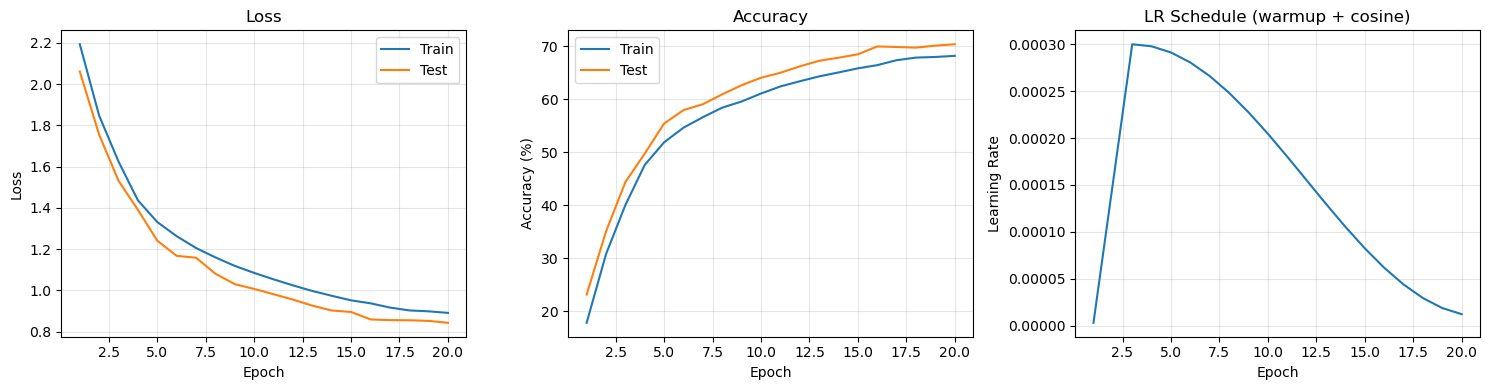

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, NUM_EPOCHS + 1)

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["test_loss"], label="Test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["test_acc"], label="Test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(epochs, history["lr"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("LR Schedule (warmup + cosine)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Visualise Attention Maps

One of the advantages of attention-based models: we can directly inspect *what the model is looking at*.

We'll visualise the attention from the **CLS token** (position 0) to all patch positions in the last transformer block. This shows which image regions the model considers most important for classification.

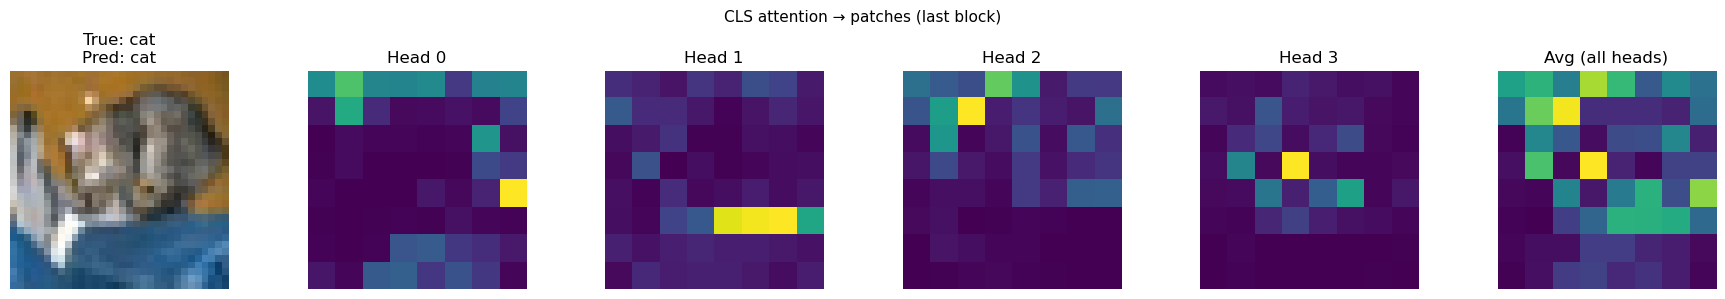

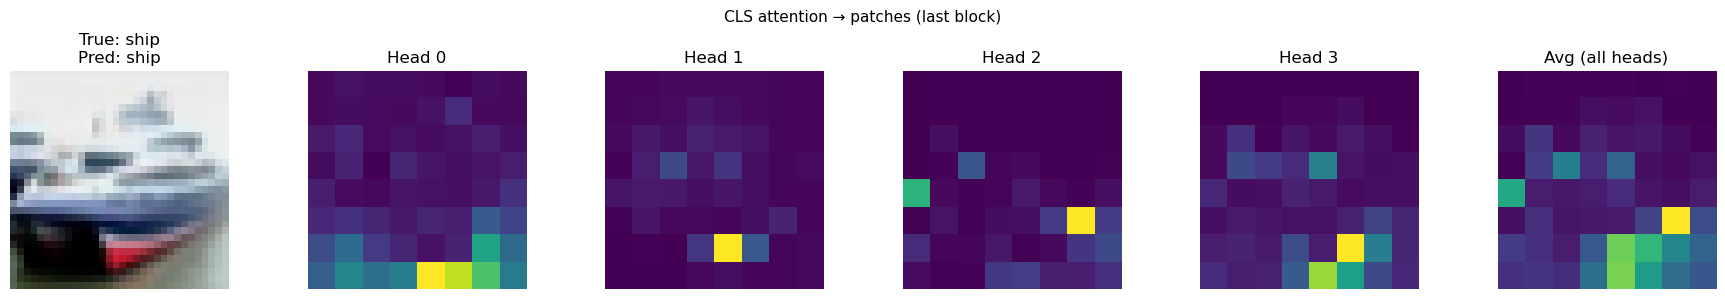

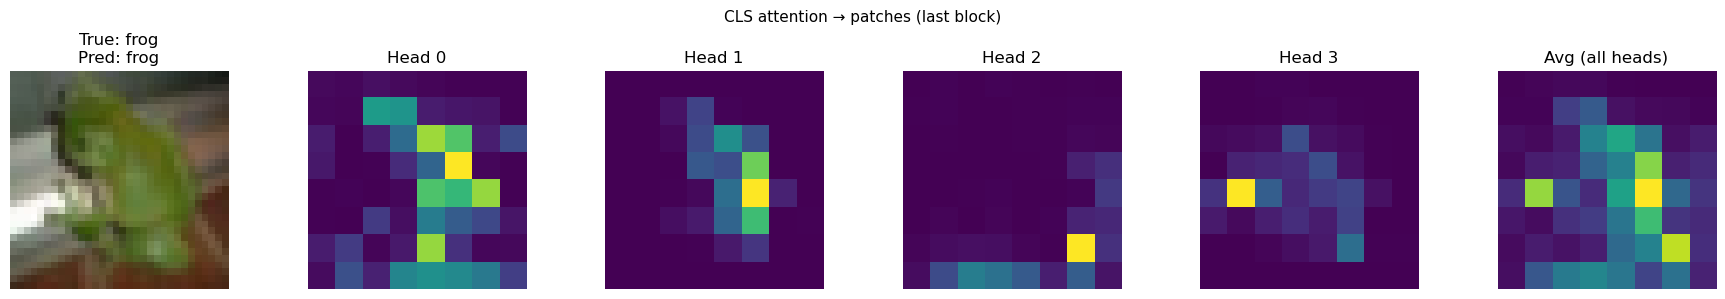

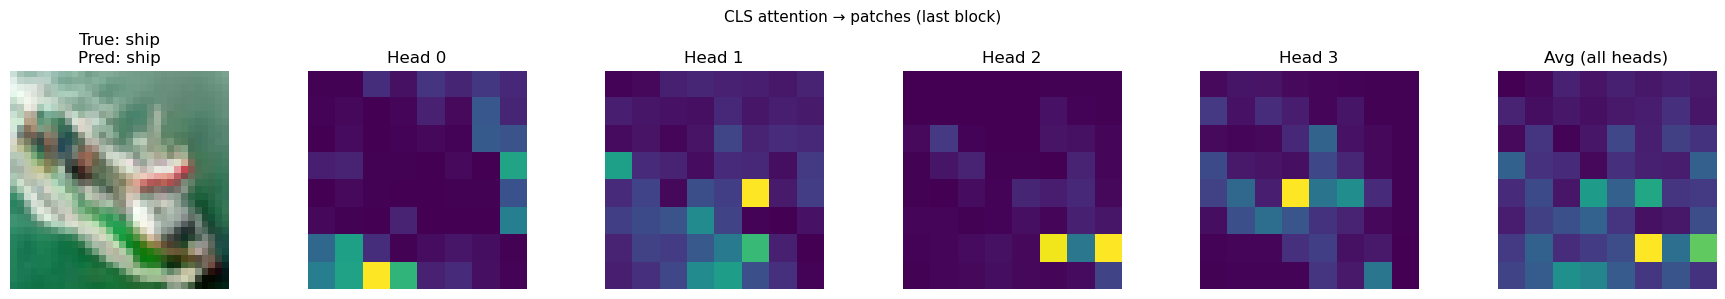

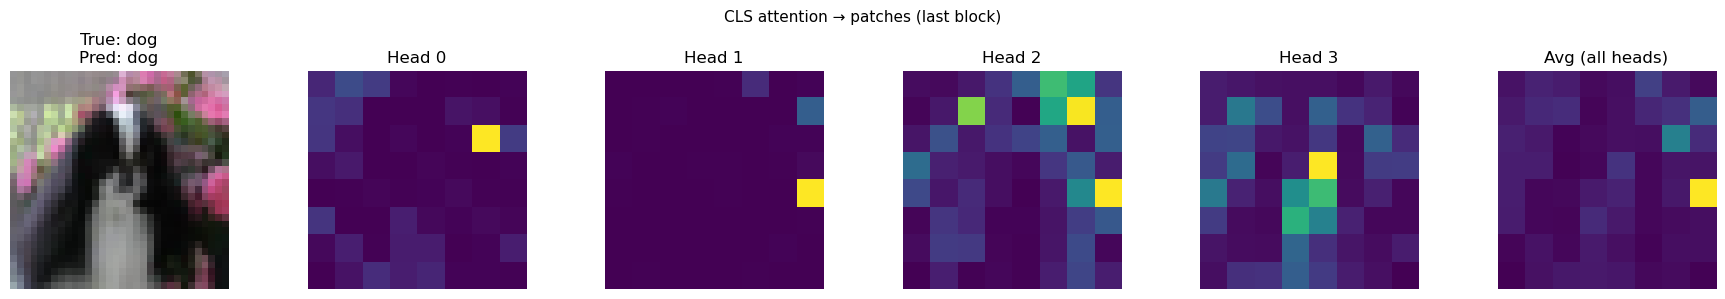

In [18]:
@torch.no_grad()
def visualise_cls_attention(
    model: MiniViT,
    dataset: torchvision.datasets.CIFAR10,
    indices: list[int],
    device: torch.device,
    mean: tuple = CIFAR10_MEAN,
    std: tuple = CIFAR10_STD,
) -> None:
    """Visualise CLS token attention over image patches.

    Shows: original image | attention map from CLS to patches (per head)
    for each sample index.
    """
    model.eval()
    grid_size = 32 // 4  # 8

    # Unnormalise for display
    inv_mean = torch.tensor(mean).view(3, 1, 1)
    inv_std = torch.tensor(std).view(3, 1, 1)

    for idx in indices:
        img_tensor, label = dataset[idx]
        img_input = img_tensor.unsqueeze(0).to(device)  # (1, 3, 32, 32)

        logits, attn_list = model(img_input, return_attention=True)
        pred = logits.argmax(dim=-1).item()

        # Get attention from the last block: (1, heads, 65, 65)
        attn = attn_list[-1].squeeze(0).cpu()  # (heads, 65, 65)

        # Extract CLS row (position 0) → patches (positions 1:)
        # Shape: (heads, 64) → reshape to (heads, 8, 8)
        cls_attn = attn[:, 0, 1:]  # drop CLS-to-CLS self-attention
        cls_attn = cls_attn.reshape(attn.shape[0], grid_size, grid_size)

        # Also compute head-averaged attention
        avg_attn = cls_attn.mean(dim=0)  # (8, 8)

        num_heads = cls_attn.shape[0]
        fig, axes = plt.subplots(1, num_heads + 2, figsize=(3 * (num_heads + 2), 3))

        # Original image (unnormalised)
        img_display = (img_tensor.cpu() * inv_std + inv_mean).clamp(0, 1)
        axes[0].imshow(img_display.permute(1, 2, 0))
        axes[0].set_title(f"True: {dataset.classes[label]}\nPred: {dataset.classes[pred]}")
        axes[0].axis("off")

        # Per-head attention maps
        for h in range(num_heads):
            axes[h + 1].imshow(cls_attn[h].numpy(), cmap="viridis", interpolation="nearest")
            axes[h + 1].set_title(f"Head {h}")
            axes[h + 1].axis("off")

        # Averaged across heads
        axes[-1].imshow(avg_attn.numpy(), cmap="viridis", interpolation="nearest")
        axes[-1].set_title("Avg (all heads)")
        axes[-1].axis("off")

        plt.suptitle(f"CLS attention → patches (last block)", fontsize=11)
        plt.tight_layout()
        plt.show()


# Visualise attention for a few test images
visualise_cls_attention(model, test_dataset, indices=[0, 1, 7, 15, 42], device=device)

---
## 11. Visualise Learned Positional Embeddings

Since the positional embeddings are learnable, we can inspect what the model has learned about spatial structure. We compute the cosine similarity between every pair of positional embeddings — nearby patches should have similar embeddings if the model has discovered 2D spatial structure.

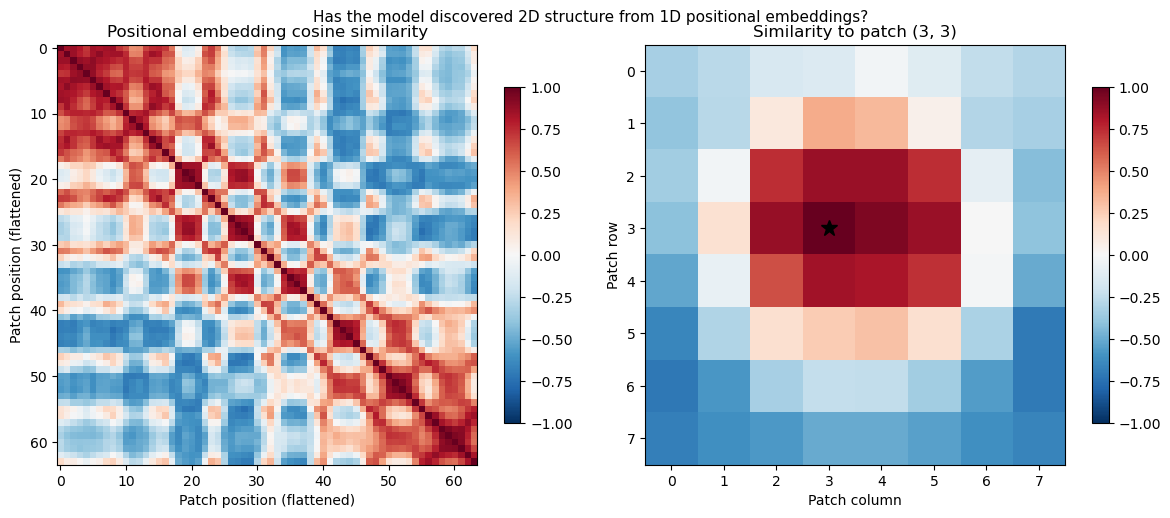

In [19]:
@torch.no_grad()
def visualise_positional_embeddings(model: MiniViT) -> None:
    """Visualise learned positional embeddings as cosine similarity matrix."""
    # Extract patch positional embeddings (skip CLS at position 0)
    pos_emb = model.pos_embed[0, 1:].cpu()  # (64, 128)

    # Cosine similarity between all pairs of positions
    pos_norm = F.normalize(pos_emb, dim=-1)  # L2-normalise
    sim_matrix = pos_norm @ pos_norm.T         # (64, 64)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: full 64×64 similarity matrix
    im = axes[0].imshow(sim_matrix.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0].set_title("Positional embedding cosine similarity")
    axes[0].set_xlabel("Patch position (flattened)")
    axes[0].set_ylabel("Patch position (flattened)")
    plt.colorbar(im, ax=axes[0], shrink=0.8)

    # Right: similarity of each position to a reference patch (centre-ish)
    ref_idx = 27  # row 3, col 3 in the 8×8 grid
    ref_sim = sim_matrix[ref_idx].reshape(8, 8)
    im2 = axes[1].imshow(ref_sim.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[1].set_title(f"Similarity to patch ({ref_idx // 8}, {ref_idx % 8})")
    axes[1].set_xlabel("Patch column")
    axes[1].set_ylabel("Patch row")
    # Mark reference patch
    axes[1].plot(ref_idx % 8, ref_idx // 8, "k*", markersize=12)
    plt.colorbar(im2, ax=axes[1], shrink=0.8)

    plt.suptitle("Has the model discovered 2D structure from 1D positional embeddings?", fontsize=11)
    plt.tight_layout()
    plt.show()


visualise_positional_embeddings(model)

---
## 12. Concept Summary

### Components we implemented from scratch

| Component | Class | Key idea |
|---|---|---|
| Patch embedding | `PatchEmbedding` | Conv2d with kernel=stride=patch_size is equivalent to flatten+linear |
| CLS token | `nn.Parameter` | Learnable token prepended to the sequence; aggregates global info |
| Positional embedding | `nn.Parameter` | Learnable 1D embeddings added to patch tokens; model discovers 2D structure |
| Multi-head self-attention | `MultiHeadSelfAttention` | Q/K/V projections → scaled dot-product → concat heads → output projection |
| Feed-forward MLP | `MLP` | Two-layer MLP with GELU; applied identically to each token |
| Transformer block | `TransformerBlock` | Pre-norm: LN → MHSA → residual → LN → MLP → residual |
| Full ViT | `MiniViT` | Patch embed → [CLS] + pos → N blocks → extract CLS → classify |

### Key PyTorch patterns used

| Pattern | Where | What it does |
|---|---|---|
| `Conv2d(kernel=stride=P)` | `PatchEmbedding` | Non-overlapping patch extraction + projection in one op |
| `.flatten(2).transpose(1,2)` | `PatchEmbedding` | Reshape conv output (B,D,H',W') to sequence (B,N,D) |
| `nn.Parameter` | CLS, pos_embed | Learnable tensors not tied to any layer |
| `.expand(B, -1, -1)` | CLS token | Broadcast (1,1,D) to (B,1,D) without copying |
| `torch.cat(dim=1)` | Prepend CLS | Structural concat requires matching non-concat dims |
| Broadcasting via `+` | Positional embed | (1, N', D) + (B, N', D) broadcasts over batch |
| Reshape for multi-head | `MHSA` | (B, N', D) → (B, h, N', d_k) to run h heads in parallel |
| `@` (matmul) | Attention scores | Batch-broadcasts over B and h dims |

### What we didn't cover (extensions)

- **Patch merging / hierarchical ViT** (Swin Transformer) — reduces sequence length at each stage
- **Relative positional bias** (Swin, RoPE) — more expressive than absolute positional embeddings
- **Register tokens** (Darcet et al., 2024) — extra learnable tokens that absorb artefacts in attention
- **Masked image modelling** (MAE, BEiT) — self-supervised pretraining for ViTs
- **Flash Attention** — memory-efficient attention that avoids materialising the full N'×N' matrix
- **KV caching** — not needed for classification but essential for autoregressive generation